# Atividade II – Previsão de Consumo de Combustível com Machine Learning (mtcars)

**Aluno:**  Cauê Reis

**Disciplina:** Aprendizagem de Máquina Profundo 

## Parte 1 – Exploração dos Dados (mtcars)

### Carregamento dos dados

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('mtcars.csv', index_col=0)

print('Shape dos dados:', df.shape)
print('\nVariáveis:', list(df.columns))
print('\nValores nulos:', df.isnull().sum().sum())

Shape dos dados: (32, 11)

Variáveis: ['mpg', 'cyl', 'disp', 'hp', 'drat', 'wt', 'qsec', 'vs', 'am', 'gear', 'carb']

Valores nulos: 0


In [3]:
df.head(10)

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
model,,,,,,,,,,,
Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2
Valiant,18.1,6,225.0,105,2.76,3.460,20.22,1,0,3,1
Duster 360,14.3,8,360.0,245,3.21,3.570,15.84,0,0,3,4
Merc 240D,24.4,4,146.7,62,3.69,3.190,20.00,1,0,4,2
Merc 230,22.8,4,140.8,95,3.92,3.150,22.90,1,0,4,2


### a) Estatísticas descritivas

In [4]:
df.describe().round(2)

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
count,32.00,32.00,32.00,32.00,32.00,32.00,32.00,32.00,32.00,32.00,32.00
mean,20.09,6.19,230.72,146.69,3.60,3.22,17.85,0.44,0.41,3.69,2.81
std,6.03,1.79,123.94,68.56,0.53,0.98,1.79,0.50,0.50,0.74,1.62
min,10.40,4.00,71.10,52.00,2.76,1.51,14.50,0.00,0.00,3.00,1.00
25%,15.42,4.00,120.82,96.50,3.08,2.58,16.89,0.00,0.00,3.00,2.00
50%,19.20,6.00,196.30,123.00,3.70,3.32,17.71,0.00,0.00,4.00,2.00
75%,22.80,8.00,326.00,180.00,3.92,3.61,18.90,1.00,1.00,4.00,4.00
max,33.90,8.00,472.00,335.00,4.93,5.42,22.90,1.00,1.00,5.00,8.00


### b) Distribuição da variável alvo (mpg)

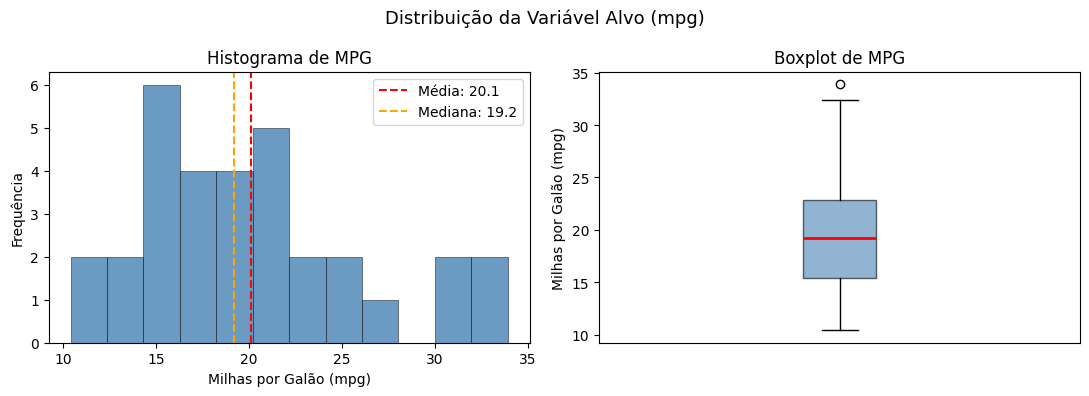

Assimetria: 0.672 | Curtose: -0.022


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(df['mpg'], bins=12, color='steelblue', edgecolor='k', linewidth=0.4, alpha=0.8)
axes[0].axvline(df['mpg'].mean(), color='red', linestyle='--', label=f"Média: {df['mpg'].mean():.1f}")
axes[0].axvline(df['mpg'].median(), color='orange', linestyle='--', label=f"Mediana: {df['mpg'].median():.1f}")
axes[0].set_title('Histograma de MPG')
axes[0].set_xlabel('Milhas por Galão (mpg)')
axes[0].set_ylabel('Frequência')
axes[0].legend()

axes[1].boxplot(df['mpg'], patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Boxplot de MPG')
axes[1].set_ylabel('Milhas por Galão (mpg)')
axes[1].set_xticks([])

plt.suptitle('Distribuição da Variável Alvo (mpg)', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Assimetria: {df["mpg"].skew():.3f} | Curtose: {df["mpg"].kurtosis():.3f}')

### c) Matriz de correlação

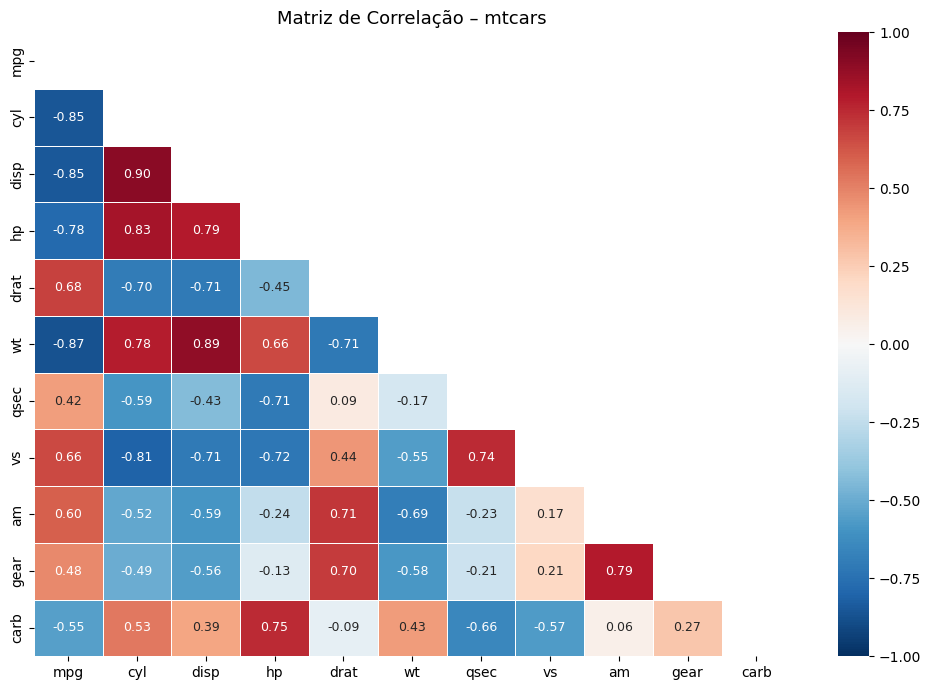


Correlação com mpg (ordenada):
drat    0.681
vs      0.664
am      0.600
gear    0.480
qsec    0.419
carb   -0.551
hp     -0.776
disp   -0.848
cyl    -0.852
wt     -0.868
Name: mpg, dtype: float64


In [6]:
import seaborn as sns

corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(10, 7))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.4, annot_kws={'size': 9})
plt.title('Matriz de Correlação – mtcars', fontsize=13)
plt.tight_layout()
plt.show()

print('\nCorrelação com mpg (ordenada):')
print(corr['mpg'].drop('mpg').sort_values(ascending=False).round(3))

### d) Relação entre mpg e os principais preditores

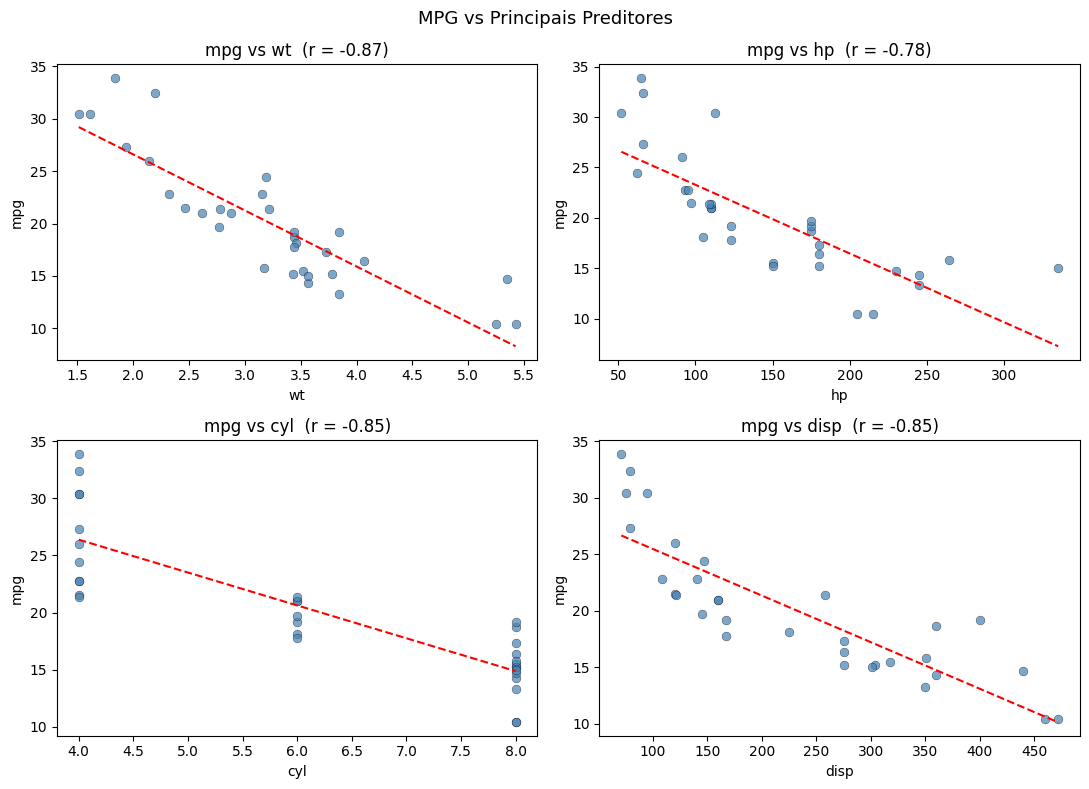

In [8]:
preditores = ['wt', 'hp', 'cyl', 'disp']

fig, axes = plt.subplots(2, 2, figsize=(11, 8))

for ax, var in zip(axes.flatten(), preditores):
    ax.scatter(df[var], df['mpg'], color='steelblue', s=40, alpha=0.7,
               edgecolors='k', linewidths=0.3)
    z = np.polyfit(df[var], df['mpg'], 1)
    xp = np.linspace(df[var].min(), df[var].max(), 100)
    ax.plot(xp, np.poly1d(z)(xp), 'r--', linewidth=1.5)
    r = df[var].corr(df['mpg'])
    ax.set_title(f'mpg vs {var}  (r = {r:.2f})')
    ax.set_xlabel(var)
    ax.set_ylabel('mpg')

plt.suptitle('MPG vs Principais Preditores', fontsize=13)
plt.tight_layout()
plt.show()

### e) MPG por número de cilindros e tipo de transmissão

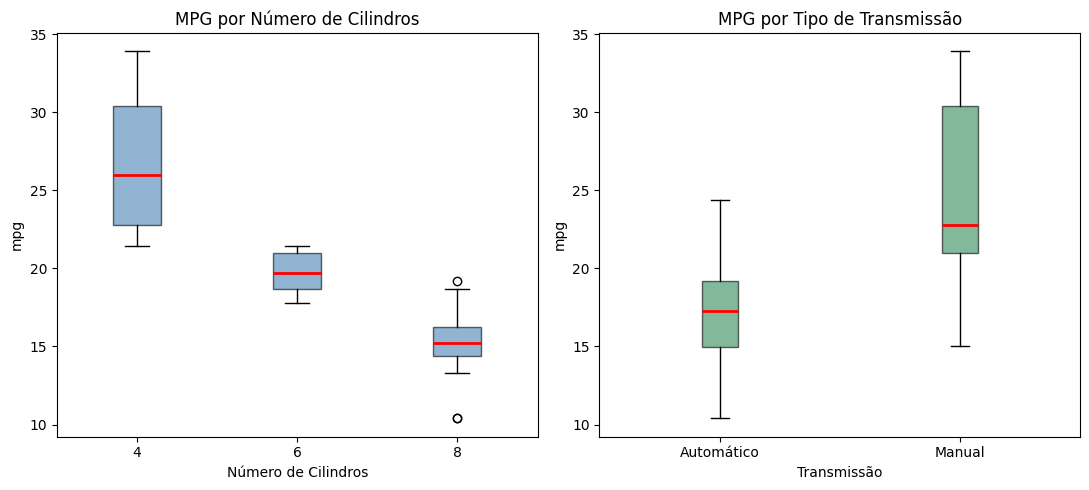

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

grupos_cyl = [df[df['cyl'] == c]['mpg'].values for c in sorted(df['cyl'].unique())]
axes[0].boxplot(grupos_cyl, patch_artist=True, labels=sorted(df['cyl'].unique()),
                boxprops=dict(facecolor='steelblue', alpha=0.6),
                medianprops=dict(color='red', linewidth=2))
axes[0].set_title('MPG por Número de Cilindros')
axes[0].set_xlabel('Número de Cilindros')
axes[0].set_ylabel('mpg')

grupos_am = [df[df['am'] == 0]['mpg'].values, df[df['am'] == 1]['mpg'].values]
axes[1].boxplot(grupos_am, patch_artist=True, labels=['Automático', 'Manual'],
                boxprops=dict(facecolor='seagreen', alpha=0.6),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('MPG por Tipo de Transmissão')
axes[1].set_xlabel('Transmissão')
axes[1].set_ylabel('mpg')

plt.tight_layout()
plt.show()

## Parte 2 – Pré-processamento dos Dados

### a) Separação entre features e variável alvo

In [10]:
X = df.drop(columns=['mpg'])
y = df['mpg']

print('Features (X):', X.shape, '→', list(X.columns))
print('Target  (y):', y.shape, '→ mpg')

Features (X): (32, 10) → ['cyl', 'disp', 'hp', 'drat', 'wt', 'qsec', 'vs', 'am', 'gear', 'carb']
Target  (y): (32,) → mpg


### b) Divisão treino/teste (80/20)

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f'Treino : {X_train.shape[0]} amostras ({X_train.shape[0]/len(df)*100:.0f}%)')
print(f'Teste  : {X_test.shape[0]} amostras ({X_test.shape[0]/len(df)*100:.0f}%)')

Treino : 25 amostras (78%)
Teste  : 7 amostras (22%)


### c) Padronização das variáveis (StandardScaler)

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

idx_wt = list(X.columns).index('wt')
print('Média antes (wt): ', X_train['wt'].mean().round(3),
      '| Média depois:', X_train_sc[:, idx_wt].mean().round(6))
print('Desvio antes (wt):', X_train['wt'].std().round(3),
      '| Desvio depois:', X_train_sc[:, idx_wt].std().round(4))

Média antes (wt):  3.142 | Média depois: 0.0
Desvio antes (wt): 0.976 | Desvio depois: 1.0


## Parte 3 – Ajuste e Comparação de Modelos

### a) Treinamento com validação cruzada 5-fold

In [13]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

modelos = {
    'Regressão Linear' : LinearRegression(),
    'Ridge'            : Ridge(alpha=1.0),
    'Lasso'            : Lasso(alpha=0.1),
    'Árvore de Decisão': DecisionTreeRegressor(random_state=42),
    'Random Forest'    : RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
resultados = []

for nome, modelo in modelos.items():
    cv_r2   = cross_val_score(modelo, X_train_sc, y_train, cv=kf, scoring='r2')
    cv_rmse = cross_val_score(modelo, X_train_sc, y_train, cv=kf,
                               scoring='neg_root_mean_squared_error')
    modelo.fit(X_train_sc, y_train)
    y_pred = modelo.predict(X_test_sc)
    resultados.append({
        'Modelo'        : nome,
        'CV R² médio'   : cv_r2.mean(),
        'CV RMSE médio' : -cv_rmse.mean(),
        'Test R²'       : r2_score(y_test, y_pred),
        'Test RMSE'     : np.sqrt(mean_squared_error(y_test, y_pred)),
        'Test MAE'      : mean_absolute_error(y_test, y_pred),
    })

df_res = pd.DataFrame(resultados).set_index('Modelo')
print(df_res.round(4))

                   CV R² médio  CV RMSE médio  Test R²  Test RMSE  Test MAE
Modelo                                                                     
Regressão Linear       -1.2525         5.2525   0.7466     3.1828    2.2411
Ridge                  -0.0702         3.8579   0.8323     2.5893    1.9946
Lasso                   0.0512         3.5831   0.8362     2.5592    1.8259
Árvore de Decisão      -0.1096         4.4617   0.8051     2.7918    2.0571
Random Forest           0.5176         2.9283   0.8567     2.3935    1.7000
Gradient Boosting       0.5055         2.8513   0.8590     2.3744    1.6650


### b) Comparação visual das métricas

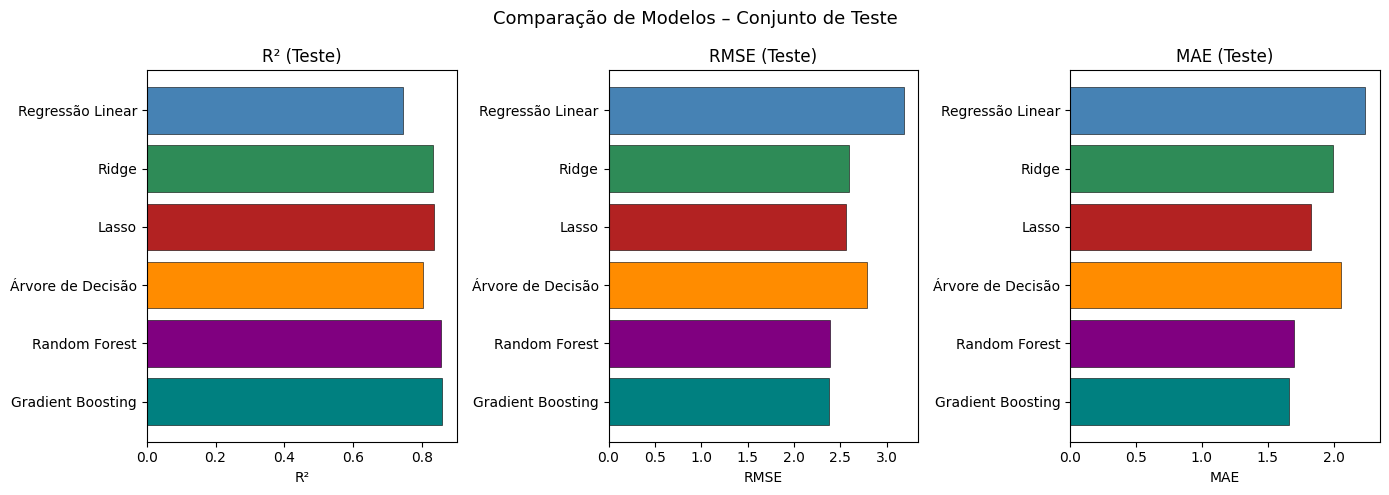

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
cores = ['steelblue', 'seagreen', 'firebrick', 'darkorange', 'purple', 'teal']
nomes = df_res.index

axes[0].barh(nomes, df_res['Test R²'], color=cores, edgecolor='k', linewidth=0.4)
axes[0].set_title('R² (Teste)')
axes[0].set_xlabel('R²')
axes[0].invert_yaxis()

axes[1].barh(nomes, df_res['Test RMSE'], color=cores, edgecolor='k', linewidth=0.4)
axes[1].set_title('RMSE (Teste)')
axes[1].set_xlabel('RMSE')
axes[1].invert_yaxis()

axes[2].barh(nomes, df_res['Test MAE'], color=cores, edgecolor='k', linewidth=0.4)
axes[2].set_title('MAE (Teste)')
axes[2].set_xlabel('MAE')
axes[2].invert_yaxis()

plt.suptitle('Comparação de Modelos – Conjunto de Teste', fontsize=13)
plt.tight_layout()
plt.show()

## Parte 4 – Análise do Melhor Modelo

### a) Identificação e predições do melhor modelo

In [15]:
melhor_nome = df_res['Test R²'].idxmax()
melhor_modelo = modelos[melhor_nome]
melhor_modelo.fit(X_train_sc, y_train)
y_pred_best = melhor_modelo.predict(X_test_sc)

print(f'Melhor modelo: {melhor_nome}')
print(df_res.loc[melhor_nome].round(4))

Melhor modelo: Gradient Boosting
CV R² médio      0.5055
CV RMSE médio    2.8513
Test R²          0.8590
Test RMSE        2.3744
Test MAE         1.6650
Name: Gradient Boosting, dtype: float64


### b) Valores reais vs preditos e análise de resíduos

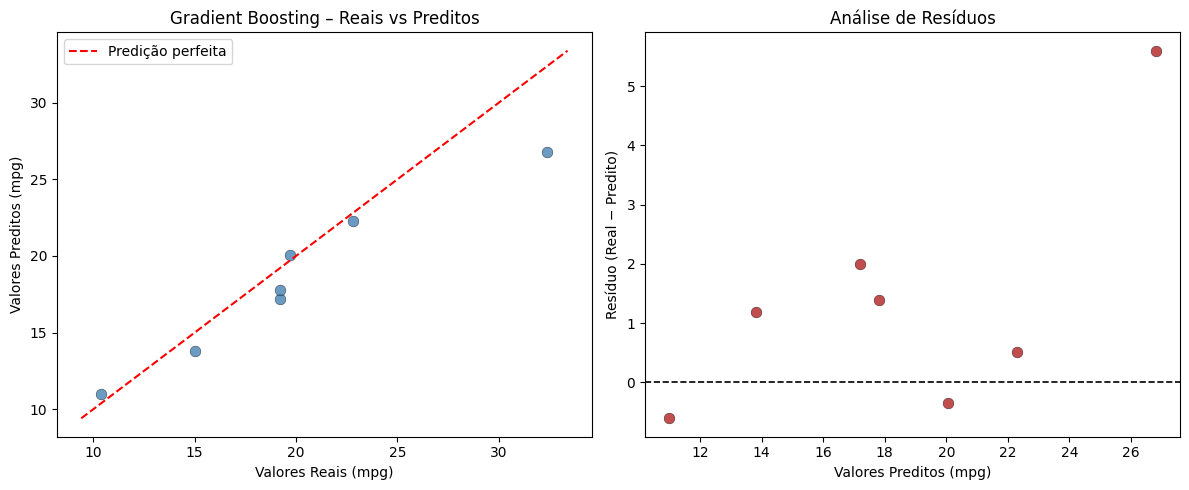

Resíduos – Média: 1.3927 | Desvio: 2.0772


In [16]:
residuos = y_test - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

lims = [min(y_test.min(), y_pred_best.min()) - 1,
        max(y_test.max(), y_pred_best.max()) + 1]
axes[0].scatter(y_test, y_pred_best, color='steelblue', s=60, alpha=0.8,
                edgecolors='k', linewidths=0.3)
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Predição perfeita')
axes[0].set_title(f'{melhor_nome} – Reais vs Preditos')
axes[0].set_xlabel('Valores Reais (mpg)')
axes[0].set_ylabel('Valores Preditos (mpg)')
axes[0].legend()

axes[1].scatter(y_pred_best, residuos, color='firebrick', s=60, alpha=0.8,
                edgecolors='k', linewidths=0.3)
axes[1].axhline(0, color='black', linestyle='--', linewidth=1.2)
axes[1].set_title('Análise de Resíduos')
axes[1].set_xlabel('Valores Preditos (mpg)')
axes[1].set_ylabel('Resíduo (Real − Predito)')

plt.tight_layout()
plt.show()

print(f'Resíduos – Média: {residuos.mean():.4f} | Desvio: {residuos.std():.4f}')

### c) Importância das features

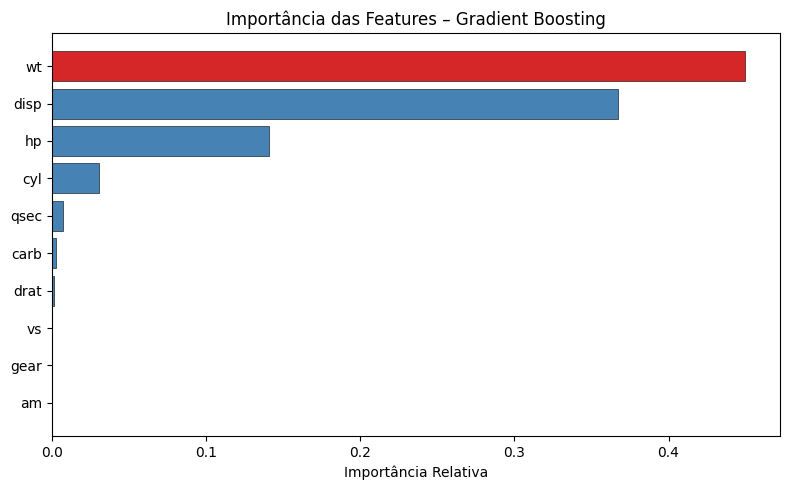


Ranking:
wt      0.4498
disp    0.3672
hp      0.1410
cyl     0.0307
qsec    0.0074
carb    0.0026
drat    0.0012
vs      0.0001
gear    0.0000
am      0.0000
dtype: float64


In [17]:
from sklearn.inspection import permutation_importance

if hasattr(melhor_modelo, 'feature_importances_'):
    imp = pd.Series(melhor_modelo.feature_importances_, index=X.columns)
    titulo = f'Importância das Features – {melhor_nome}'
else:
    perm = permutation_importance(melhor_modelo, X_test_sc, y_test,
                                   n_repeats=30, random_state=42)
    imp = pd.Series(perm.importances_mean, index=X.columns)
    titulo = f'Permutation Importance – {melhor_nome}'

imp_sorted = imp.sort_values(ascending=True)
cores_imp = ['#d62728' if v == imp_sorted.max() else 'steelblue' for v in imp_sorted]

plt.figure(figsize=(8, 5))
plt.barh(imp_sorted.index, imp_sorted.values, color=cores_imp,
         edgecolor='k', linewidth=0.4)
plt.title(titulo, fontsize=12)
plt.xlabel('Importância Relativa')
plt.tight_layout()
plt.show()

print('\nRanking:')
print(imp.sort_values(ascending=False).round(4))

### d) Coeficientes da Regressão Linear (interpretabilidade)

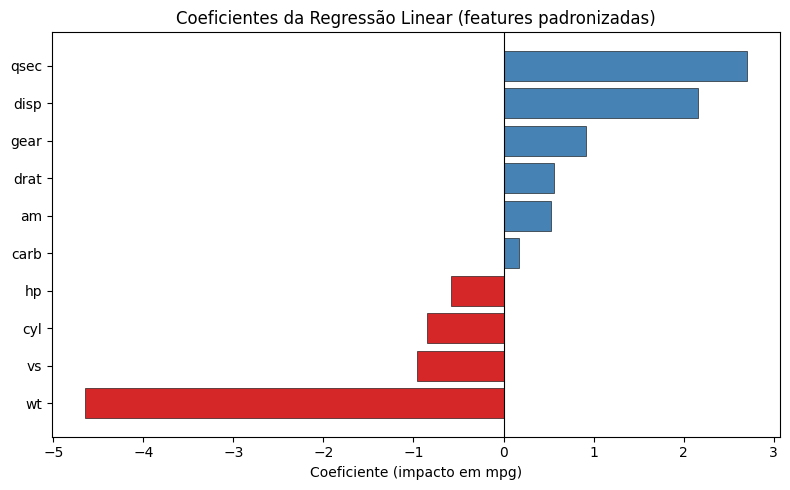

Intercepto: 20.1680
wt     -4.6493
vs     -0.9616
cyl    -0.8485
hp     -0.5803
carb    0.1722
am      0.5274
drat    0.5595
gear    0.9194
disp    2.1581
qsec    2.7034
dtype: float64


In [18]:
lr = LinearRegression()
lr.fit(X_train_sc, y_train)

coef = pd.Series(lr.coef_, index=X.columns).sort_values()
cores_coef = ['#d62728' if v < 0 else 'steelblue' for v in coef]

plt.figure(figsize=(8, 5))
plt.barh(coef.index, coef.values, color=cores_coef, edgecolor='k', linewidth=0.4)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Coeficientes da Regressão Linear (features padronizadas)', fontsize=12)
plt.xlabel('Coeficiente (impacto em mpg)')
plt.tight_layout()
plt.show()

print(f'Intercepto: {lr.intercept_:.4f}')
print(coef.round(4))